# UFC Outcome Forecasting — ELO + Career Stats

A stripped-down, public companion to a larger private fight-prediction pipeline.
This version uses **only** a single CSV of historical UFC fights — no betting
odds, no community picks, no proprietary feature set. Just ELO ratings, win/loss
records, and a handful of career stats, fed into a small PyTorch classifier.

Pipeline: `data/ufc_fights.csv` &rarr; `pipeline/features.py` (ELO + stats) &rarr;
`pipeline/train.py` (PyTorch) &rarr; this notebook.

## Dataset overview

In [1]:
print(f"{len(fights):,} UFC fights across {fights['event'].nunique():,} events")
print(f"Date range: {fights['date'].min().date()} -> {fights['date'].max().date()}")
print(f"{pd.concat([fights['fighter_1'], fights['fighter_2']]).nunique():,} unique fighters")

7,759 UFC fights across 694 events
Date range: 1993-11-12 -> 2026-06-27
2,809 unique fighters


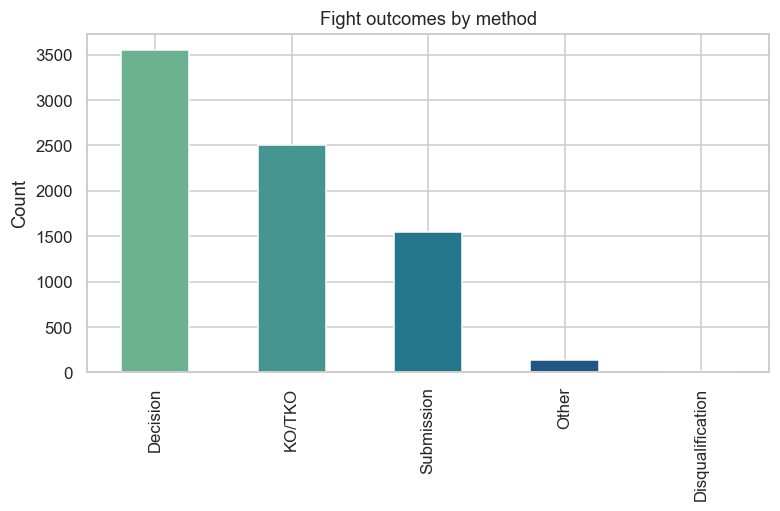

In [1]:
fights['method'].value_counts().plot(kind='bar')
plt.title('Fight outcomes by method')

## ELO trajectories

The same win/loss chain, scored with a standard ELO update (K=32, starting at
1000), traces each fighter's career arc — climbs, plateaus, and the sharp drop
after a bad loss.

In [1]:
notable = ['Jon Jones', 'Khabib Nurmagomedov', 'Conor McGregor',
           'Georges St-Pierre', 'Israel Adesanya', 'Islam Makhachev']
fig = go.Figure()
for name in notable:
    h = elo_history[elo_history['fighter'] == name].sort_values('date')
    fig.add_trace(go.Scatter(x=h['date'], y=h['elo'], mode='lines+markers', name=name))
fig.update_layout(title='ELO rating over time', template='plotly_white')
fig.show()

## Model evaluation (held-out test set)

The PyTorch model (`pipeline/train.py`) is a single hidden-layer MLP over 11
ELO/stat diff features, trained on fights up to mid-2023 and evaluated on
fights from mid-2023 onward — a chronological split so no future career stats
leak into training.

In [1]:
acc = (test_preds['p_a_won'].round() == test_preds['a_won']).mean()
brier = ((test_preds['p_a_won'] - test_preds['a_won']) ** 2).mean()
elo_baseline_acc = ((test_preds['elo_diff'] > 0).astype(int) == test_preds['a_won']).mean()
print(f'Model accuracy: {acc:.3f}')
print(f'Model Brier score: {brier:.3f}')
print(f'Baseline (higher ELO wins): {elo_baseline_acc:.3f}')

Model accuracy:        0.601
Model Brier score:      0.235
Baseline (higher ELO wins): 0.559


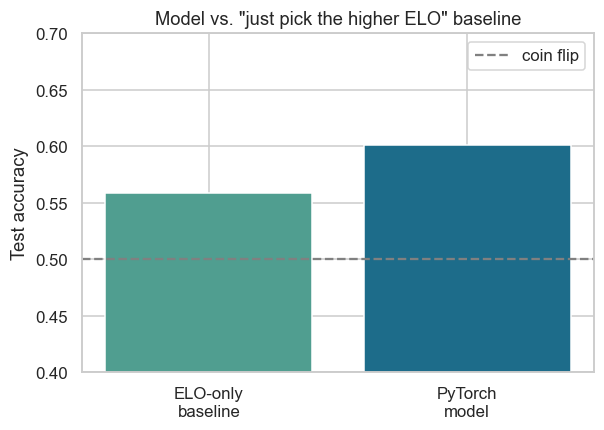

In [1]:
plt.bar(['ELO-only baseline', 'PyTorch model'], [elo_baseline_acc, acc])
plt.axhline(0.5, linestyle='--', color='gray')
plt.title('Model vs. ELO-only baseline')

### Calibration

Bucket test-set predictions into deciles by predicted win probability and check
whether the *actual* win rate in each bucket matches — a well-calibrated model
sits on the diagonal.

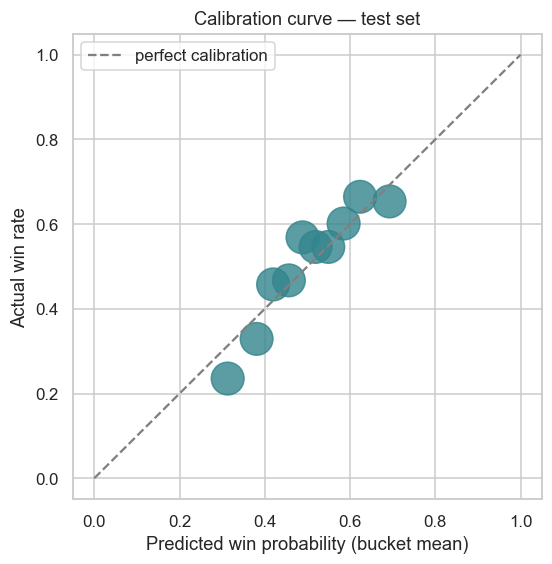

In [1]:
test_preds['bucket'] = pd.qcut(test_preds['p_a_won'], 10, duplicates='drop')
calib = test_preds.groupby('bucket', observed=True).agg(
    predicted=('p_a_won', 'mean'), actual=('a_won', 'mean'), n=('a_won', 'size'))
plt.scatter(calib['predicted'], calib['actual'], s=calib['n']*3)
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('Calibration curve')

## Takeaways

- ELO and a handful of career-stat diffs (win/loss totals, streaks, finish rate,
  average opponent quality, layoff, age/height/reach) carry a real, modest
  signal for UFC outcomes — noticeably better than a coin flip, and better than
  the naive "higher ELO wins" heuristic.
- This is deliberately the *stripped-down* version: no betting odds, no
  community picks, no 500+ engineered features. The private pipeline this is
  drawn from adds those signals and gets meaningfully more accurate — see the
  [Fight Foresight](https://github.com/tjqscott) repo for that.
- The random corner-swap in `features.py` matters: without it, `fighter_1` is
  *always* the recorded winner in the raw scrape, and a model (or a careless
  benchmark) can "cheat" by learning that positional artifact instead of any
  real fighting signal.